In [ ]:
!nvidia-smi

Thu Nov 20 22:48:44 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 550.54.15              Driver Version: 550.54.15      CUDA Version: 12.4     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   38C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [ ]:
!pip install cuml-cu12 --extra-index-url=https://pypi.nvidia.com

Looking in indexes: https://pypi.org/simple, https://pypi.nvidia.com


In [ ]:
import pandas as pd
import numpy as np
import os
from google.colab import drive
import matplotlib.pyplot as plt
import seaborn as sns
import uuid
import json
import joblib
from cuml.ensemble import RandomForestClassifier  # GPU-accelerated sklearn-like RF
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

# Executable Code

In [ ]:
def load_leaf_data(base_path, node_id):
    """
    Loads (X, y) for a specific leaf node using its node_id.
    """

    # Walk through directories searching for node_id
    for root, dirs, files in os.walk(base_path):
        if os.path.basename(root) == node_id:
            data_path = os.path.join(root, "data.joblib")
            if not os.path.exists(data_path):
                raise ValueError(f"Node {node_id} exists but has no leaf data.")

            return joblib.load(data_path)

    raise ValueError(f"Node {node_id} not found under {base_path}.")

def load_leaf_path(base_path, node_id):
    """
    Gives full path for a specific leaf node using its node_id.
    """

    # Walk through directories searching for node_id
    for root, dirs, files in os.walk(base_path):
        if os.path.basename(root) == node_id:
            data_path = os.path.join(root, "data.joblib")
            if not os.path.exists(data_path):
                raise ValueError(f"Node {node_id} exists but has no leaf data.")

            return root

    raise ValueError(f"Node {node_id} not found under {base_path}.")

In [ ]:
# -----------------------------
# 1. Load data from a leaf
# -----------------------------
drive.mount('/content/drive')

model_path = "/content/drive/Shared drives/Gestió de Projectes/Projecte/saved_model"
leaf_id = "e4097e96-1c11-4d3c-adfa-568b8e941b98"  # <-- you will replace this

X, y = load_leaf_data(model_path, leaf_id)

X = pd.DataFrame(X)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
le = joblib.load(os.path.join(model_path, "label_encoder.joblib"))

In [ ]:
# -----------------------------
# 2. Delete dimensions with no variance
# -----------------------------

# Identify columns where all values are identical
zero_var_cols = X.columns[X.nunique() <= 1]

print("Columns with zero variance:", list(zero_var_cols))

# Drop them
X = X.drop(columns=zero_var_cols)

Columns with zero variance: ['Subministrament (€/m³)', 'Tarifes socials']


In [ ]:
# -----------------------------
# 3. Split into train/test 80-20
# -----------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    shuffle=True
)

# -----------------------------
# 4. Define GPU Random Forest
# -----------------------------
# Hyperparameters suitable for ~1 million rows
rf = RandomForestClassifier(
    n_estimators=200,      # fewer trees than CPU version (GPU parallelizes well)
    max_depth=18,          # prevents memory blow-up
    max_features="sqrt",
    n_bins=64,             # GPU optimized histogram bins
    bootstrap=True,
    n_streams=8,           # parallel GPU streams
    random_state=42
)

# -----------------------------
# 5. Train the model
# -----------------------------
rf.fit(X_train, y_train)

# Optional: evaluate
accuracy = rf.score(X_test, y_test)
print("Test accuracy:", accuracy)


Test accuracy: 0.9954701957159833


Test accuracy: 0.9954701957159833


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        68
     1052800       0.00      0.00      0.00       892
      163840       0.99      1.00      1.00    172010
      167936       1.00      1.00      1.00      3379
       32768       1.00      1.00      1.00      3228
       33024       1.00      1.00      1.00     12340
        8192       1.00      1.00      1.00      5001

    accuracy                           1.00    196918
   macro avg       0.86      0.86      0.86    196918
weighted avg       0.99      1.00      0.99    196918



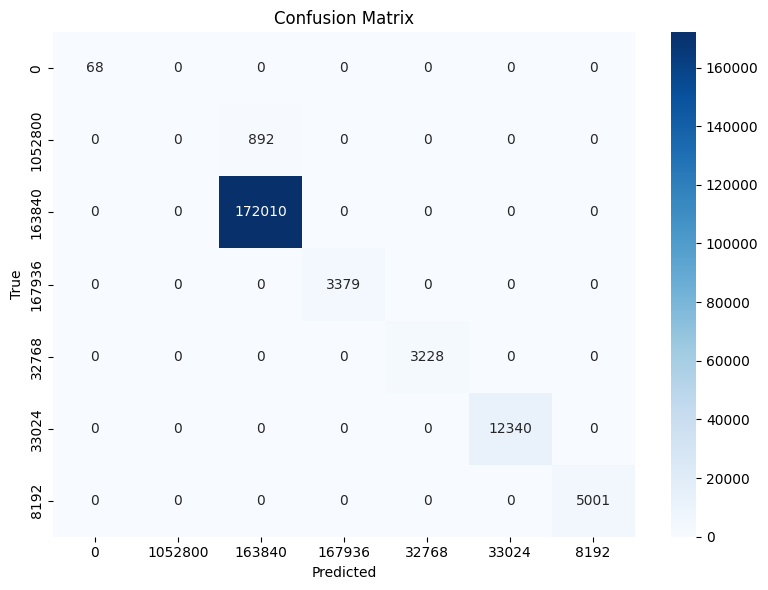

In [ ]:
# -----------------------------
# Evaluation
# -----------------------------

y_pred = rf.predict(X_test)
acc = accuracy_score(y_test, y_pred)
print("Test accuracy:", acc)


unique_labels = np.unique(np.concatenate([y_test, y_pred]))
class_names = [le.classes_[i] for i in unique_labels]

# Confusion matrix

cm = confusion_matrix(y_test, y_pred, labels=unique_labels)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=class_names, yticklabels=class_names)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.tight_layout()

# Classification report

report = classification_report(y_test, y_pred, labels=unique_labels, target_names=class_names)
print("Classification Report:\n", report)

Model and evaluation saved to: /content/drive/Shared drives/Gestió de Projectes/Projecte/saved_model/10f65179-dd9c-4d6c-9312-e266dceec286/27a86291-1253-4635-b6e2-fe2be4e66783/f6dc1e79-db70-4648-a96b-5521b6408a3b/e4097e96-1c11-4d3c-adfa-568b8e941b98/forest_model


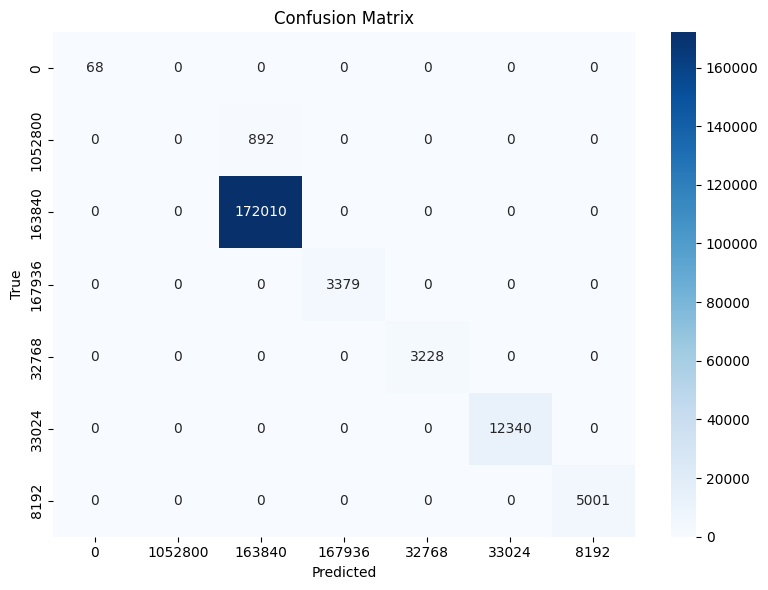

In [ ]:
# -----------------------------
# Saving everything
# -----------------------------

leaf_folder = load_leaf_path(model_path, leaf_id)
save_folder = os.path.join(leaf_folder, "forest_model")
os.makedirs(save_folder, exist_ok=True)

# Save the model

model_file = os.path.join(save_folder, "rf_model.joblib")
joblib.dump(rf, model_file)

# Save plots

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=class_names, yticklabels=class_names)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.tight_layout()
plt.savefig(os.path.join(save_folder, "confusion_matrix.png"))

# Save evaluation text

with open(os.path.join(save_folder, "evaluation.txt"), "w") as f:
    f.write(f"Test Accuracy: {acc}\n\n")
    f.write("Classification Report:\n")
    f.write(report)

print(f"Model and evaluation saved to: {save_folder}")